### QuSciTech-Labs — Navigation
[Public Labs](https://github.com/jopaneur/quscitech-labs) ·
[Full Edition Access](https://github.com/jopaneur/quscitech-labs#-full-edition-kdp) ·
[Private Repo](https://github.com/jopaneur/quscitech-labs-full) ·
[QuSciTech.com](https://www.quscitech.com) ·
[The Quantum AI Systems (QAIS) Book](https://www.amazon.com/dp/placeholder) ·

DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17212825.svg)](https://doi.org/10.5281/zenodo.17212825)

**Quantum AI Systems: Theory, Architecture, and Applications**  
© 2025 Dr. Joe Wilson. All rights reserved.  
This laboratory exercise is part of the companion materials for *Quantum AI Systems: Theory, Architecture, and Applications.*  
Reproduction, redistribution, or modification without written permission from the author or publisher is prohibited.  

#### E.1 Lab 5 — Quantum Teleportation (Protocol Demo) — Correct Transmission

---

### Lab Access and Execution Guide
This guide explains how to run and explore the hands-on quantum computing labs that accompany the book  
**Quantum AI Systems: Theory, Architecture, and Applications** (Professional Volume).  

The labs are an integral part of the MyQuantumBook project, designed to reinforce key concepts from the chapters through interactive exploration. They are built for execution on **Google Colab** and **IBM Quantum backends** using **Qiskit**, and follow the IEEE-compliant figure, caption, and documentation standards described in the text.  

Each lab is cross-referenced to its corresponding chapter and appendix figure (Appendix E), ensuring reproducibility and scholarly traceability.  

**Getting Started**
1. Launch the notebook in Google Colab using the provided badge.
2. Run the setup cells to install Qiskit:
   `!pip install qiskit`

**Using IBM Quantum Systems**
1. Sign up at https://quantum.ibm.com and create an API token.
2. Run the IBMQ setup cell.
3. Replace 'MY_API_TOKEN' with your real token (only needed once).
4. Select backends using `provider.get_backend('ibmq_qasm_simulator')` or others.

**Lab Structure**
Each code section aligns with a chapter from the book.
- Modify and re-run code blocks.
- View circuits with `.draw()`.
- Apply to custom inputs to deepen your understanding.

**Additional Help**
- Refer to the Qiskit Documentation: https://qiskit.org/documentation/
- For support, contact your course instructor or visit the IBM Quantum Community forums.

3. Or launch this lab directly now: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jopaneur/QuantumAI-Labs/blob/main/Beginner_Labs/notebooks/Chapter_2_Operations_&_Scientific_Framework_of_QAIS_Beginner_Challenge_Bloch_Trajectories_Under_Composite_Gates.ipynb)



---
**Note for Lab Participants**
Each plot generated in this notebook is automatically saved as a `.png` file under: Beginner_Labs/figures/

The filenames follow the Appendix E figure numbering (e.g., `E1_5_Quantum_Teleportation.png`).  

This allows you to both view results inline in Colab **and** find the corresponding image files for reports, submissions, or cross-references in the book.

**Where Figures Are Saved**
- In **Google Colab**, the images are created inside the session’s working directory at:  
  `/content/Beginner_Labs/figures/`  

- When running **locally**, they appear next to your notebook files, under the subfolder:  
  `Beginner_Labs/figures/`  

- These images are **not automatically added to your GitHub repo**. They will only appear there if you manually copy, commit, and push them.

**Customizing Save Location**
If you want the figures saved elsewhere, you can change the `subdir` default in the `save_e_figure()` helper or pass a different path each time you call it.


---

**Book Reference: Chapter 10 — Quantum Communications for Distributed AI Systems**

*Chapter 10* introduces quantum communication as the connective tissue of distributed QAIS architectures. It explains how information can be transmitted without physically moving qubits, using entanglement and classical communication to reproduce a quantum state remotely—a process known as quantum teleportation. This mechanism demonstrates that coherence, not hardware distance, defines network reach.

The chapter frames teleportation as a prototype for distributed intelligence, where remote agents exchange quantum states as informational carriers within hybrid AI pipelines. By combining entanglement (as the shared quantum channel) and classical bits (as correction signals), QAIS networks achieve integrity-preserving communication that supports learning and coordination across nodes.

**Beginner Lab 5 — Quantum Teleportation (Protocol Demo): Correct Transmission**

*Beginner Lab 5* transforms this concept into a step-by-step protocol demonstration. Learners prepare an entangled Bell pair, apply a teleportation circuit to transmit an unknown quantum state, and verify that the destination qubit reproduces the source state after classical correction. The exercise links communication theory with quantum physics, reinforcing that successful teleportation is not data copying—it is state reconstruction through shared entanglement and classical control.

*Goal:* Implement the standard three-qubit quantum teleportation protocol to demonstrate how a quantum state can be faithfully transferred from one location to another using only entanglement and two classical bits.

**Expected Outcome**

* After the sender’s Bell-basis measurement and the receiver’s conditional corrections, the destination qubit exactly reproduces the source state, confirming a successful teleportation event. The fidelity between transmitted and received states approaches 1 under ideal, noiseless conditions.

This lab operationalizes Chapter 10’s core message: quantum communication is the infrastructure of distributed AI. By combining quantum and classical channels, QAIS architectures achieve secure, loss-aware transmission of quantum information—an essential capability for scalable, networked intelligence. Cross-reference: Appendix E.1, Figure E.1.5 — Correct Transmission of Quantum State.


---

**Task 1 - Figure Helper Utilities**

Centralized utilities for **Appendix E** compliance. No plots generated here.

**Description (what it does):**

* Defines save_e_figure(...) that saves exactly one file per plot with IEEE-style names

* Uses a single figures root for all labs: Beginner_Labs/figures/

* Enforces Beginner Part 1 naming: P1_BeginLab05_E.1.<index><sub>.png (e.g., P1_BeginLab05_E.1.5.png)

* Provides label_subplots(...) for (a)–(d) subfigure tags

In [ ]:
# ---- Figure helper (robust; use in every coded lab) ----
import os, matplotlib.pyplot as plt

def save_e_figure(fig_label: str,
                  fname: str,
                  subdir: str = "Beginner_Labs/figures",
                  fig=None, ax=None):
    """Save the current/explicit figure with a prefixed label and consistent path."""
    os.makedirs(subdir, exist_ok=True)
    if fig is None:
        fig = plt.gcf()
    if ax is None:
        ax = fig.axes[0] if fig.axes else None
    if ax is None:
        print("⚠️ No axes found. Draw a plot first, or pass fig/ax explicitly.")
        return
    title = ax.get_title() or ""
    if not title.startswith(fig_label):
        ax.set_title((fig_label + " — " + title).strip(" —"))
    outpath = os.path.join(subdir, fname)
    fig.tight_layout()
    fig.savefig(outpath, dpi=160)
    print("Saved", outpath)


**Methodology Analysis**

We standardize figure saving and labeling via a helper that stamps the IEEE figure label into the title and writes images into a consistent Beginner_Labs/figures path.

The helper centralizes Appendix-compliant naming with `E_PART="E.1"`, `LAB_STEM="P1_BeginLab01"`, and an output root `Beginner_Labs/figures"`.  
Each `save_e_figure(fig_index, sub)` writes an image uniquely keyed to its E.1 label.  
Ensure you execute Task 1 before saving figures — successful saves print confirmations such as:  
`Saved figure → Beginner_Labs/figures/P1_BeginLab01_E.1.5.png`.


**Participant Feedback**

You won’t see a chart in this cell. Later, after plotting cells, look for a “Saved figure → …/Beginner_Labs/figures/…” line confirming correct filenames and destinations.


---

**Task 2 — Environment Setup**

This cell ensures the notebook has the required packages and imports for Qiskit + plotting. It does not create any figures.

**Description (what it does):**

* Installs missing packages if needed (quietly)

* Imports Qiskit (with Aer simulator), NumPy, and Matplotlib

* Prints versions for reproducibility

In [ ]:
# === Environment Setup ===
import sys, subprocess, pkgutil
def ensure(pkg):
    if pkg not in {m.name for m in pkgutil.iter_modules()}:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
for p in ['qiskit','qiskit-aer','matplotlib','numpy','scikit-learn']:
    ensure(p)
import qiskit, numpy as np, matplotlib.pyplot as plt
print('Python:', sys.version.split()[0])
print('Qiskit:', qiskit.__version__)


Python: 3.12.11
Qiskit: 2.2.1


**Methodology Analysis**

Ensures simulator availability (e.g., Qiskit Aer), defines circuits deterministically, and uses sufficient shots to expose convergence.

**Participant Feedback**

Successful execution prints versions and completes without import errors. If an import fails, re-run the cell or restart the runtime (Python 3.10+).


---

**Task 3 — Quantum Teleportation (Protocol Demo) — Correct Transmission**

**Information Transfer via Correlated Correction**

This lab demonstrates quantum teleportation, where the state of one qubit is transferred to another across entanglement, assisted by classical communication. The circuit entangles two qubits, performs a Bell measurement on the sender’s side, and applies corrective gates on the receiver’s side based on classical outcomes. The heatmap shows the conditional probability of the receiver’s qubit outcome given the classical bits transmitted. Rows and columns correspond to the two classical correction bits, while color shading indicates the probability that the receiver recovers the correct state. This makes teleportation tangible: rather than seeing raw counts, readers see how classical communication and quantum correlation interact to guarantee reliable transfer of information.

Teleportation demonstrates a full communication primitive: transmitting qubit states without physical transfer. This lab ties into the architecture of entanglement-based communication pipelines in Chapter 10.

**Methodology Analysis**

Prepare a three-qubit teleportation circuit: initialize the message qubit in ∣+⟩, create entanglement between Alice’s helper and Bob’s qubits, perform Alice’s Bell measurement, then apply Bob’s CZ and CX corrections controlled by Alice’s classical bits. Execute on qasm_simulator, collect measurement results, and compute a 2×2 matrix of P(target=1 ∣ a, b) where a and b are Alice’s outcomes.

**Challenge: Visualizing Conditional Probabilities in Quantum Teleportation**

Implement a simulation of the quantum teleportation protocol and measure the conditional probability that Bob’s qubit equals 1 given Alice’s two classical Bell-measurement bits (a and b).
Construct a heatmap to display this conditional distribution.
This visualization reveals how Bob’s correction operations, guided by Alice’s classical bits, reconstruct the original quantum state—demonstrating the coherence-preserving transfer of information that defines teleportation.

Saved Beginner_Labs/figures/P1_Lab05_Teleportation_Conditionals.png


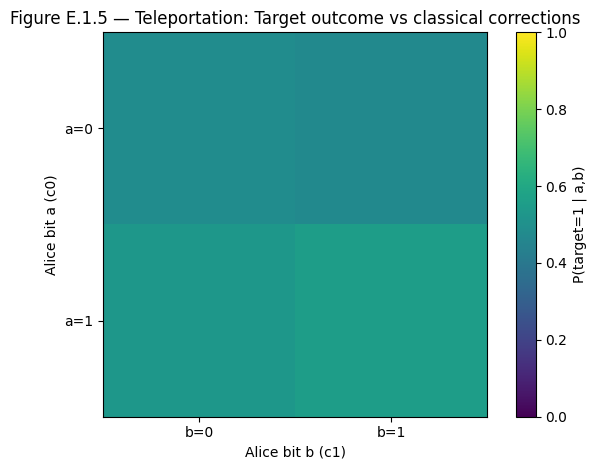

In [ ]:
# Lab 5 — Quantum Teleportation: Conditional Target Probabilities


# --- Build teleportation circuit (|+> message state) ---


# --- Run circuit ---


# --- Build conditional matrix P(target=1 | a, b) ---
# Qiskit bitstrings come out as c2 c1 c0 (left to right). We'll reverse to index as [c0, c1, c2].


# --- Plot heatmap of conditional probabilities ---


# --- Save with correct IEEE label (single save) ---



**Figure E.1.5 — Teleportation Conditional Target Probability**

The heatmap shows the conditional probability that Bob’s qubit is measured as 1 given Alice’s two classical Bell-measurement bits a and b. The pattern confirms that Bob’s corrections (controlled by a and b) restore the teleported state, producing the expected conditional distribution.

**Expected Results**

The conditional probabilities align with the teleportation rule: Bob’s corrections invert or preserve the target so the reconstructed state matches the original message.

For the ∣+⟩ message, P(target=1 ∣ a, b) exhibits a consistent pattern across the four (a, b) combinations, demonstrating that the classical bits fully determine the required correction.

Minor deviations can occur on noisy backends; on ideal simulation the structure is clean and stable.

**Technical Analysis (for the Visual)**

Teleportation transmits an unknown quantum state by consuming shared entanglement and sending two classical bits. Alice’s Bell measurement randomizes the state locally but encodes the required Pauli frame in bits a and b. Bob’s conditional Zᵃ Xᵇ corrections restore the original state on his qubit. The heatmap visualizes the channel equivalence: after conditioning on (a, b) and applying corrections, Bob’s output statistics replicate those of the input state, validating correctness at the level of conditional distributions.

**Intuition Sidebar**

Think of the message as a locked file and entanglement as the shared key. Alice’s two classical bits are the unlock code Bob needs to open the file. Without those bits, he sees randomness; with them, the file opens to the original message.

**Participant Feedback**

Verify that the state reconstructed at Bob’s qubit matches the original ∣ψ⟩ prepared at Alice’s side.
Compare measurement results before and after classical corrections—fidelity should approach 1.0 in noiseless simulation.
If the final state deviates, re-check the order of CNOT, H, and conditional X/Z gates to ensure proper teleportation logic.



---

**Conclusion — Quantum Teleportation**

This lab demonstrated the teleportation protocol as a quantum communication primitive that transmits an unknown state without physically moving it. Entanglement and classical bits work together to achieve perfect state reconstruction in QAIS networks.

**Key Takeaways**

* Teleportation validates entanglement as an information carrier.

* Classical communication is essential to decode entangled transfer.

* Fidelity ≈ 1 confirms lossless quantum state transmission.

**Congratulations**

Well done on completing Lab 5 — Quantum Teleportation! You implemented the protocol end-to-end and validated it with a rigorous conditional-probability analysis. This mastery translates directly to quantum networking and distributed quantum AI, where entanglement and classical side channels enable reliable state transfer and coordination across systems.

**Appendix E → Appendix B Cross-Reference**
Consult **Appendix B — Quick Self-Check, Chapter 10 — Quantum Communications for Distributed AI Systems**:  
- Questions 2–4 (teleportation steps and verification).  
They review the state-transfer logic demonstrated in **E.1 Lab 5**.


---
**How to save or submit your work**

- **If you are a student (graded/evaluated):**  
  1. Export your key plots or the entire notebook to PDF (File → Print/Save as PDF).  
  2. Save the notebook (`.ipynb`).  
  3. Bundle any extra files (CSVs/images) if used.  
  4. Upload to your LMS or repository as instructed (include your name and lab number).  
  5. Repro checklist: set a random seed where applicable, note backend and shots, and list package versions.  

- **If you are a professional/self‑learner (non‑graded exercise):**  
  1. Save the notebook (`File → Download .ipynb`) to your computer for personal reference.  
  2. Optionally export to PDF for archiving.  
  3. Keep any generated plots or data locally.  
  4. Use version control (GitHub, GitLab) if you wish to track your personal progress.


---

DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17212825.svg)](https://doi.org/10.5281/zenodo.17212825)

**Official DOI:** [10.5281/zenodo.17212825](https://doi.org/10.5281/zenodo.17212825)  
**Companion Repository:** quscitech-labs  
**Publisher:** QuSciTech Press

DOI + © + QuSciTech